In [1]:
import pandas as pd
import numpy as np
import os
import kagglehub

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

### Explanation: Library Imports
In this cell, we import all the necessary Python libraries:
* **`pandas` and `numpy`**: For data manipulation and numerical operations.
* **`os` and `kagglehub`**: To handle file paths and download datasets directly from Kaggle.
* **`matplotlib.pyplot` and `seaborn`**: For creating visualizations and plotting distributions.
* **`sklearn` utilities**: For splitting our dataset, preprocessing categorical labels, building predictive models (like Decision Tree and Random Forest), and evaluating performance metrics.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("denkuznetz/food-delivery-time-prediction")

print("Path to dataset files:", path)

100%|██████████| 11.6k/11.6k [00:00<00:00, 13.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/denkuznetz/food-delivery-time-prediction/versions/1


### Explanation: Downloading Dataset
This cell utilizes the `kagglehub` API to programmatically download the latest version of the "Food Delivery Time Prediction" dataset and prints the directory path where the files are stored.

In [3]:
df = pd.read_csv(os.path.join(path,"Food_Delivery_Times.csv"))

### Explanation: Loading the Data
Here, we use `pandas.read_csv()` to read the downloaded CSV file `Food_Delivery_Times.csv` from our dataset path into a DataFrame named `df`.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Explanation: Data Summary
Calling `df.info()` displays a summary of our DataFrame, including the total number of entries (1,000), column names, non-null counts, and data types (numeric vs object/categorical columns).

In [5]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


### Explanation: Checking for Missing Values
We calculate and display the total number of missing (`NaN`) values in each column. This helps identify columns like `Weather`, `Traffic_Level`, `Time_of_Day`, and `Courier_Experience_yrs` which contain missing entries.

In [6]:
Weather_le = LabelEncoder()
Traffic_Level_le = LabelEncoder()
Time_of_Day_le = LabelEncoder()
Vehicle_Type_le = LabelEncoder()
df['Weather'] = Weather_le.fit_transform(df['Weather'])
df['Traffic_Level'] = Traffic_Level_le.fit_transform(df['Traffic_Level'])
df['Vehicle_Type'] = Vehicle_Type_le.fit_transform(df['Vehicle_Type'])
df['Time_of_Day'] = Time_of_Day_le.fit_transform(df['Time_of_Day'])



### Explanation: Categorical Variable Encoding
We initialize `LabelEncoder` objects for our categorical features (`Weather`, `Traffic_Level`, `Vehicle_Type`, and `Time_of_Day`) and convert these text values into numerical categories using `fit_transform`.

In [7]:
df["Weather"] = df["Weather"].fillna(df["Weather"].mean())
df["Traffic_Level"] = df["Traffic_Level"].fillna(df["Traffic_Level"].mean())
df["Time_of_Day"] = df["Time_of_Day"].fillna(df["Time_of_Day"].mean())
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(df["Courier_Experience_yrs"].mean())

### Explanation: Handling Missing Values
Since we have missing data, we impute (fill) the missing values in `Weather`, `Traffic_Level`, `Time_of_Day`, and `Courier_Experience_yrs` using the mean of each respective column.

In [8]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


### Explanation: Post-Imputation Check
We run `df.isnull().sum()` again to confirm that all missing values have been successfully filled and there are no remaining null values in our dataset.

In [9]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,12,1.0,43
1,738,16.42,0,2,1,0,20,2.0,84
2,741,9.52,1,1,3,2,28,1.0,59
3,661,7.44,2,2,0,2,5,1.0,37
4,412,19.03,0,1,2,0,16,5.0,68


### Explanation: Viewing Data Sample
We use `df.head()` to inspect the first 5 rows of our processed DataFrame and verify that categorical values have been successfully encoded into numerical representations.

In [10]:
df = df.drop(["Order_ID"], axis=1)

### Explanation: Dropping Irrelevant Features
We drop the `Order_ID` column from our dataset because unique identification numbers do not provide any predictive power for our machine learning model.

In [11]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


### Explanation: Verifying Column Drop
We check the head of the DataFrame again to make sure `Order_ID` has been removed and only our model features remain.

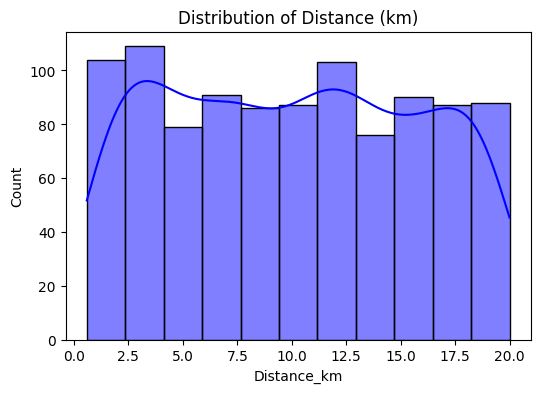

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns




plt.figure(figsize=(6, 4))
sns.histplot(df['Distance_km'], kde=True, color='blue')
plt.title('Distribution of Distance (km)')
plt.show()

### Explanation: Visualizing Feature Distribution
We use Seaborn's `histplot` with a Kernel Density Estimate (KDE) curve to visualize how the delivery distances (`Distance_km`) are distributed across our dataset.

Weather
0    470
2    204
1    103
3     97
4     96
5     30
Name: count, dtype: int64
Weather
0    47.0
2    20.4
1    10.3
3     9.7
4     9.6
5     3.0
Name: proportion, dtype: float64


/tmp/ipykernel_7569/3750312982.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index, palette='Blues_r')


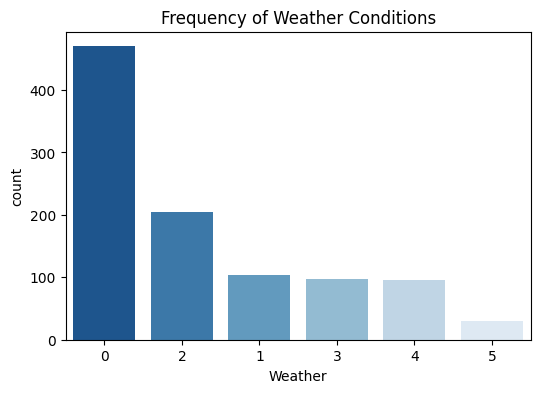

In [13]:
# Value Counts & Percentages
print(df['Weather'].value_counts())
print(df['Weather'].value_counts(normalize=True) * 100)

# Count Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index, palette='Blues_r')
plt.title('Frequency of Weather Conditions')
plt.show()


### Explanation: Categorical Frequency Distribution
Here, we print the counts and relative percentages of the encoded `Weather` conditions and plot their frequencies using a countplot to understand our data balance.

/tmp/ipykernel_7569/2685467439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Traffic_Level', palette='Oranges_r')


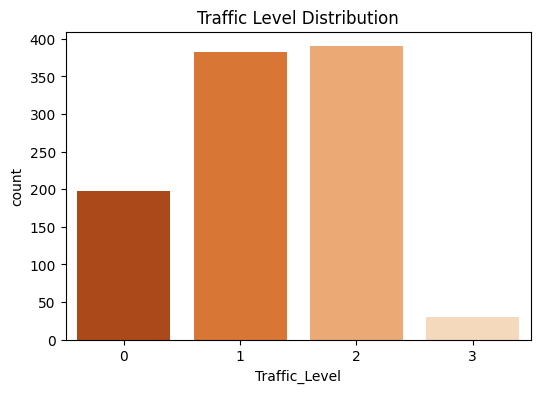

In [14]:

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Traffic_Level', palette='Oranges_r')
plt.title('Traffic Level Distribution')
plt.show()


### Explanation: Traffic Levels Countplot
Similarly, we generate a countplot to visualize the frequency of different `Traffic_Level` scenarios in our dataset.

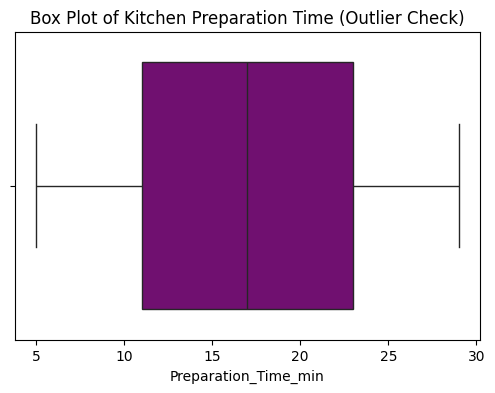

In [15]:

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Preparation_Time_min'], color='purple')
plt.title('Box Plot of Kitchen Preparation Time (Outlier Check)')
plt.show()


### Explanation: Outlier Detection using Boxplots
We construct a boxplot of kitchen preparation time (`Preparation_Time_min`) to visually inspect the spread of data and check for any extreme value anomalies (outliers).

In [16]:
import pandas as pd
import numpy as np

# Select the numeric column you want to check
column_name = 'Delivery_Time_min'

# Calculate Quantiles
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1

# Define Fences
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Filter and extract outlier entries
outliers = df[(df[column_name] < lower_fence) | (df[column_name] > upper_fence)]
print(f"Total outliers detected in {column_name}: {len(outliers)}")
print(outliers[[column_name]])


Total outliers detected in Delivery_Time_min: 6
     Delivery_Time_min
29                 123
127                141
379                153
452                141
784                126
924                122


### Explanation: Calculating Interquartile Range (IQR) for Outliers
We mathematically identify outliers in our target variable (`Delivery_Time_min`) by calculating the Interquartile Range (IQR) and setting lower and upper boundaries (fences).

In [17]:
df

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,0,0,1,1,13,3.0,54
996,16.28,2,1,2,2,8,9.0,71
997,15.62,3,0,1,2,26,2.0,81
998,14.17,0,1,0,0,8,0.0,55


### Explanation: Inspecting the Dataset
We display the full DataFrame to inspect our numerical values and ensure everything looks correct before proceeding to final preprocessing.

In [18]:
import numpy as np


Q1 = df['Delivery_Time_min'].quantile(0.25)
Q3 = df['Delivery_Time_min'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

df['Delivery_Time_min'] = np.where(
    df['Delivery_Time_min'] > upper_fence, upper_fence,
    np.where(df['Delivery_Time_min'] < lower_fence, lower_fence, df['Delivery_Time_min'])
)

print(f"Capping complete. Lower fence: {lower_fence:.2f}, Upper fence: {upper_fence:.2f}")


Capping complete. Lower fence: -4.00, Upper fence: 116.00


### Explanation: Outlier Capping
To prevent outliers from skewing our predictions, we "cap" any values in `Delivery_Time_min` that exceed our upper fence (116.00) or fall below our lower fence (-4.00) using `np.where()`.

In [19]:
X = df.drop(columns=["Delivery_Time_min"])
y = df["Delivery_Time_min"]

### Explanation: Feature and Target Splitting
We split our dataset into `X` (our input features used to make predictions, excluding the target) and `y` (the target column we want to predict, which is `Delivery_Time_min`).

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Explanation: Train-Test Split
We divide our features and targets into training sets (80%) and testing sets (20%) using `train_test_split`. We set `random_state=42` to ensure our results are reproducible.

In [21]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Explanation: Model Selection
We import and initialize a `RandomForestRegressor` with 100 decision trees, and import standard regression metrics (`MAE`, `MSE`, `R2 Score`) to measure model performance.

In [22]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### Explanation: Model Training
We train our Random Forest model on the training data (`X_train` and `y_train`) using the `.fit()` method so it can learn the relationships between the features and delivery times.

In [23]:
y_pred = rf_model.predict(X_test)

### Explanation: Making Predictions
We use our newly trained model to predict delivery times for our unseen testing dataset (`X_test`).

In [24]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

### Explanation: Calculating Performance Metrics
We compute key performance metrics to evaluate our predictions:
* **`r2_score`**: Explains the proportion of variance in the target variable predicted by our model.
* **`mean_absolute_error` (MAE)**: Measures the average magnitude of absolute prediction errors.
* **`mean_squared_error` (RMSE)**: Penalizes larger errors and represents the standard deviation of our prediction residuals.

In [25]:
r2

0.7808730970886244

### Explanation: R2 Score Output
This cell displays the R-squared value (~0.78), showing that our model successfully accounts for approximately 78% of the variance in delivery times.

In [26]:
mae

6.968800000000001

### Explanation: MAE Output
This displays the Mean Absolute Error, which indicates that our model's predictions are, on average, about 6.97 minutes off from the actual delivery times.

In [38]:
rmse

np.float64(9.868272138525569)

### Explanation: RMSE Output
This displays our Root Mean Squared Error (~9.87 minutes), representing the typical error size while applying more weight to larger errors.

In [39]:
import joblib

# =========================
# DUMP / SAVE
# =========================

model_data = {
    "model": rf_model,
    "Weather_le": Weather_le,
    "Traffic_Level_le": Traffic_Level_le,
    "Time_of_Day_le": Time_of_Day_le,
    "Vehicle_Type_le": Vehicle_Type_le
}

joblib.dump(model_data, "traffic_rf_model.joblib")

print("Model and encoders dumped successfully!")


# =========================
# LOAD
# =========================

loaded_data = joblib.load("traffic_rf_model.joblib")

rf_model = loaded_data["model"]
Weather_le = loaded_data["Weather_le"]
Traffic_Level_le = loaded_data["Traffic_Level_le"]
Time_of_Day_le = loaded_data["Time_of_Day_le"]
Vehicle_Type_le = loaded_data["Vehicle_Type_le"]

print("Model and encoders loaded successfully!")

Model and encoders dumped successfully!
Model and encoders loaded successfully!


### Explanation: Model Saving and Loading (Serialization)
In this final cell:
* **Saving**: We pack our trained `rf_model` along with all four label encoders into a dictionary named `model_data` and write it to disk using `joblib.dump()`. This allows us to use the same encoding logic when serving predictions later.
* **Loading**: We test reloading the serialized model using `joblib.load()` to ensure everything can be restored successfully for production use.